# CAB320 Assignment 2 - Transfer Learning
Anthony Vanderkop, Thierry Peynot, Frederic Maire (Jupyter Notebook template: 2025)


## Instructions:
The functions and classes defined in this module will be called by the marker without modification. 
You should complete the functions and classes according to their specified interfaces.

No partial marks will be awarded for functions that do not meet the specifications of the interfaces.


In [35]:
### LIBRARY IMPORTS ###
import os
import numpy as np
import keras.applications as ka
import keras
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import time

## Task 1
Implement the my_team()function 

In [36]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [
        ('n11285915', 'Nour', 'Spear'),
        ('n11323442', 'Joshua', 'Oates'),
        ('n12116785', 'Joshua', 'George'),
    ]

In [37]:
my_team()

[('n11285915', 'Nour', 'Spear'),
 ('n11323442', 'Joshua', 'Oates'),
 ('n12116785', 'Joshua', 'George')]

## Task 2
Download the small_flower_dataset from Canvas and load the data

In [38]:
def load_data(path):
    '''
    Load in the dataset from its home path. Path should be a string of the path
    to the home directory the dataset is found in. Should return a numpy array
    with paired images and class labels.
    
    Insert a more detailed description here.

    Returns:
        X: numpy array of shape (n_samples, 224, 224, 3)
        Y: numpy array of shape (n_samples,)
    '''
    # ensures imported path is in the correct file system format
    data_root = os.fspath(path)
    nested_root = os.path.join(data_root, 'small_flower_dataset')

    # handles the extra folder level created when the zip file is unzipped
    if os.path.isdir(nested_root):
        data_root = nested_root

    # stops the function if the dataset folder cannot be found
    if not os.path.isdir(data_root):
        raise FileNotFoundError(f'Dataset folder not found: {path}')

    # loads the images from each class folder and resizes them for MobileNetV2
    image_dataset = keras.utils.image_dataset_from_directory(
        data_root,
        labels='inferred',
        label_mode='int',
        color_mode='rgb',
        batch_size=None,
        image_size=(224, 224),
        shuffle=False,
        verbose=False,
    )

    # creates empty lists to store the loaded images and their labels
    images = []
    labels = []

    # preprocesses each image and stores its matching class label
    for image, label in image_dataset:
        images.append(ka.mobilenet_v2.preprocess_input(image.numpy()))
        labels.append(int(label.numpy()))

    # saves the class names so the label numbers can be checked later
    load_data.class_names = tuple(image_dataset.class_names)

    # returns images and labels as numpy arrays for the next tasks
    return np.asarray(images, dtype=np.float32), np.asarray(labels, dtype=np.int64)

In [39]:
X, Y = load_data('small_flower_dataset')
X.shape, Y.shape, load_data.class_names

((1000, 224, 224, 3),
 (1000,),
 ('daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'))

## Task 3
Prepare your training, validation and test sets for the non-accelerated version of transfer learning.

In [40]:
def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    """
    Split the data into training and testing sets. If eval_set is True, also create
    an evaluation dataset. There should be two outputs if eval_set there should
    be three outputs (train, test, eval), otherwise two outputs (train, test).
    
    To see what type train, test, and eval should be, refer to the inputs of 
    transfer_learning().
    
    Insert a more detailed description here.

    Returns:
        train_set: tuple of training images and labels in the form (X_train, Y_train)
        eval_set: tuple of validation images and labels in the form (X_eval, Y_eval), if eval_set is True
        test_set: tuple of testing images and labels in the form (X_test, Y_test)
    """
    # checks that the image data and labels contain the same number of samples
    X = np.asarray(X)
    Y = np.asarray(Y)

    if len(X) != len(Y):
        raise ValueError('X and Y must contain the same number of samples')

    if train_fraction <= 0 or train_fraction >= 1:
        raise ValueError('train_fraction must be between 0 and 1')

    # creates empty lists to store the split image and label groups
    train_images = []
    train_labels = []
    eval_images = []
    eval_labels = []
    test_images = []
    test_labels = []

    # splits each class separately so the final sets stay balanced
    for class_label in np.unique(Y):
        # joins the image data and labels together so they stay matched when shuffled
        class_indices = np.where(Y == class_label)[0]

        # shuffles the dataset only when randomize is set to True
        if randomize:
            class_indices = np.random.permutation(class_indices)

        # calculates how many samples should go into the training set
        train_count = int(len(class_indices) * train_fraction)

        if train_count == 0 or train_count == len(class_indices):
            raise ValueError('train_fraction creates an empty train or test split')

        train_indices = class_indices[:train_count]
        remaining_indices = class_indices[train_count:]

        train_images.append(X[train_indices])
        train_labels.append(Y[train_indices])

        # uses the remaining samples for the test set when no evaluation set is needed
        if not eval_set:
            test_indices = remaining_indices

        # splits the remaining samples into validation and test sets when eval_set is True
        else:
            eval_count = len(remaining_indices) // 2
            eval_indices = remaining_indices[:eval_count]
            test_indices = remaining_indices[eval_count:]

            eval_images.append(X[eval_indices])
            eval_labels.append(Y[eval_indices])

        test_images.append(X[test_indices])
        test_labels.append(Y[test_indices])

    # combines each class split back into one training set and one testing set
    X_train = np.concatenate(train_images, axis=0)
    Y_train = np.concatenate(train_labels, axis=0)
    X_test = np.concatenate(test_images, axis=0)
    Y_test = np.concatenate(test_labels, axis=0)

    # combines the validation groups only when an evaluation set is needed
    if eval_set:
        X_eval = np.concatenate(eval_images, axis=0)
        Y_eval = np.concatenate(eval_labels, axis=0)

    # shuffles the final sets so the classes are not grouped together
    if randomize:
        train_order = np.random.permutation(len(Y_train))
        test_order = np.random.permutation(len(Y_test))

        X_train = X_train[train_order]
        Y_train = Y_train[train_order]
        X_test = X_test[test_order]
        Y_test = Y_test[test_order]

        if eval_set:
            eval_order = np.random.permutation(len(Y_eval))
            X_eval = X_eval[eval_order]
            Y_eval = Y_eval[eval_order]

    # returns the split data as tuples in the format required by transfer_learning()
    train_set = (X_train, Y_train)
    test_set = (X_test, Y_test)

    if eval_set:
        validation_set = (X_eval, Y_eval)
        return train_set, validation_set, test_set

    return train_set, test_set

In [41]:
train_set, eval_set, test_set = split_data(X, Y, 0.7, randomize=True, eval_set=True)

Report: Include details of how you have split the data to perform this training. Ensure the split is reasonable and does not introduce class imbalance during training

- The dataset was split after loading the images and labels using:

```python
train_set, eval_set, test_set = split_data(X, Y, 0.7, randomize=True, eval_set=True)
```

- A 70% / 15% / 15% split was used.
- 70% of the data was used for training.
- 15% of the data was used for validation/evaluation.
- 15% of the data was used for testing.
- Since the dataset contains 1000 images across 5 classes, this gives 700 training images, 150 validation images, and 150 testing images.
- Each class has 200 images, so the split keeps the classes balanced.
- Each class has 140 training images, 30 validation images, and 30 testing images.
- The split is done separately for each class before combining the data back together.
- This prevents class imbalance because each flower type contributes the same proportion of images to each set.
- The training set is used to update the model weights.
- The validation/evaluation set is used during training to monitor performance on unseen data.
- The test set is kept separate and should only be used after training to measure final model performance.
- `randomize=True` shuffles the image order so the model does not train on images grouped by class.
- The function returns each split as a tuple in the form `(images, labels)`.
- This format matches the expected input format for the later `transfer_learning()` function.


## Task 4
Using the tf.keras.applications module download a pretrained MobileNetV2 network. 

In [42]:
def load_model():
    '''
    Load a pretrained MobileNetV2 model and return it.

    The model uses ImageNet weights and the same 224x224 RGB input shape
    used when the flower images were loaded in Task 2. The original
    ImageNet classification head is kept here because Task 5 replaces the
    final layer with a Dense layer for the five flower classes.

    Returns:
        model: pretrained MobileNetV2 model loaded with ImageNet weights
    '''
    model = ka.MobileNetV2(
        weights='imagenet',
        include_top=True,
        input_shape=(224, 224, 3),
    )

    # returns the downloaded model so it can be passed into transfer_learning()
    return model

In [43]:
model = load_model()
model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_34[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Task 5
Replace the last layer of the downloaded neural network with a Dense layer of the appropriate shape for the 5 classes of the small flower dataset {(x1,t1), (x2,t2),..., (xm,tm)}.

## Task 6
Compile and train your model with an SGD optimizer using the following parameters learning_rate=0.01, momentum=0.0, nesterov=False. (NB: The SGD class description can be found at https://keras.io/api/optimizers/sgd/  )

In [44]:
def replace_classification_layer(model, num_classes=5):
    '''
    Replace the pretrained MobileNetV2 ImageNet classifier with a Dense
    layer for the flower dataset classes.

    Inputs:
        - model: pretrained MobileNetV2 model returned by load_model()
        - num_classes: number of flower classes to classify

    Outputs:
        - model: keras.Model with the original MobileNetV2 input and a
            num_classes-unit Dense softmax output layer
    '''
    # keeps the original MobileNetV2 input so Task 2 images still match the model
    model_input = model.input

    # takes the feature vector from the layer before the original ImageNet classifier
    feature_output = model.layers[-2].output

    # creates one softmax probability output for each flower class
    flower_output = keras.layers.Dense(
        num_classes,
        activation='softmax',
        name='flower_predictions',
    )(feature_output)

    # rebuilds the network using the pretrained feature extractor and new classifier
    flower_model = keras.Model(
        inputs=model_input,
        outputs=flower_output,
        name='mobilenetv2_flower_classifier',
    )

    # freezes the pretrained MobileNetV2 layers so only the new Dense head trains later
    for layer in flower_model.layers[:-1]:
        layer.trainable = False

    # keeps the replacement classifier trainable for Task 6
    flower_model.layers[-1].trainable = True

    # Outputs: return the model with a 5-class flower prediction layer
    return flower_model


def transfer_learning(train_set, eval_set, model, parameters):
    '''
    Implement and perform standard transfer learning here.

    Inputs:
        - train_set: list or tuple of the training images and labels in the
            form (images, labels) for training the classifier
        - eval_set: list or tuple of the images and labels used in evaluating
            the model during training, in the form (images, labels)
        - model: an instance of tf.keras.applications.MobileNetV2
        - parameters: list or tuple of parameters to use during training:
            (learning_rate, momentum, nesterov)


    Outputs:
        - model : keras.Model with MobileNetV2 features and a 5-class Dense
            softmax output layer for the flower dataset

    '''
    # Task 5: replace the original 1000-class ImageNet layer with a 5-class flower layer
    model = replace_classification_layer(model, num_classes=5)

    # unpacks the required SGD settings from the parameters tuple
    learning_rate, momentum, nesterov = parameters

    # creates the SGD optimizer required for Task 6
    optimizer = keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        nesterov=nesterov,
    )

    # compiles the model for integer class labels and multi-class prediction
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    # separates the image arrays and class labels for Keras model.fit()
    train_images, train_labels = train_set
    eval_images, eval_labels = eval_set

    # trains only the new flower classifier while monitoring validation performance
    history = model.fit(
        train_images,
        train_labels,
        validation_data=(eval_images, eval_labels),
        epochs=10,
        batch_size=32,
        verbose=1,
    )

    # stores the fit history on the model so Task 7 can plot loss and accuracy curves
    model.training_history = history

    # Outputs: return the compiled and trained 5-class flower classifier
    return model

In [45]:
model = transfer_learning(train_set, eval_set, model, (0.01, 0.0, False))
model.summary()

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 215ms/step - accuracy: 0.4986 - loss: 1.3013 - val_accuracy: 0.6933 - val_loss: 0.9745
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.7229 - loss: 0.7981 - val_accuracy: 0.7267 - val_loss: 0.7666
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.8071 - loss: 0.6224 - val_accuracy: 0.7533 - val_loss: 0.6758
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.8429 - loss: 0.5308 - val_accuracy: 0.7933 - val_loss: 0.6176
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8557 - loss: 0.4675 - val_accuracy: 0.8067 - val_loss: 0.5924
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.8743 - loss: 0.4163 - val_accuracy: 0.8133 - val_loss: 0.5592
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8871 - loss: 0.3855 - val_accuracy: 0.8067 - val_loss: 0.5411
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.9057 - loss: 0.3543 - val_accuracy: 0.

Model: "mobilenetv2_flower_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_34[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,264,391 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

## Task 7
Plot the training and validation errors and accuracies of standard transfer 

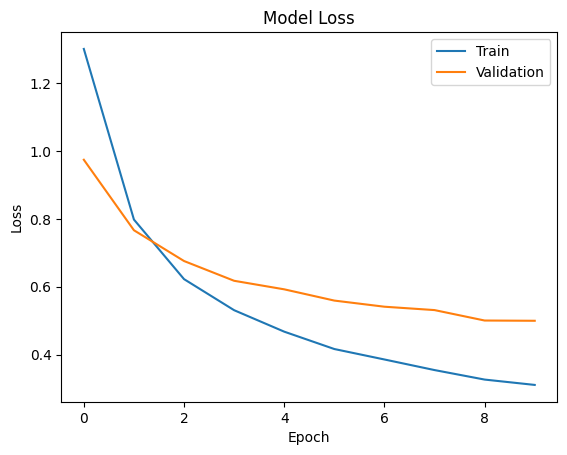

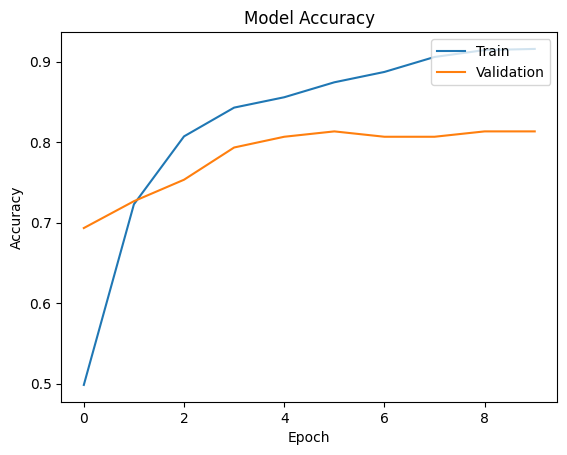

In [46]:
## Your Code
history = model.training_history
# Plot training & validation loss values
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Plot training & validation accuracy values values
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

## Task 8
Experiment with 3 different orders of magnitude for the learning rate. Plot the results and discuss in the below markdown cell

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.5986 - loss: 1.8889 - val_accuracy: 0.7333 - val_loss: 0.8171
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.8386 - loss: 0.4454 - val_accuracy: 0.8067 - val_loss: 0.5659
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.9357 - loss: 0.2097 - val_accuracy: 0.8333 - val_loss: 0.4101
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.9600 - loss: 0.1412 - val_accuracy: 0.8600 - val_loss: 0.3836
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.9743 - loss: 0.1011 - val_accuracy: 0.8667 - val_loss: 0.4183
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.9857 - loss: 0.0826 - val_accuracy: 0.8467 - val_loss: 0.4239
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.9943 - loss: 0.0650 - val_accuracy: 0.8267 - val_loss: 0.4479
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.9971 - loss: 0.0576 - val_accuracy: 0.

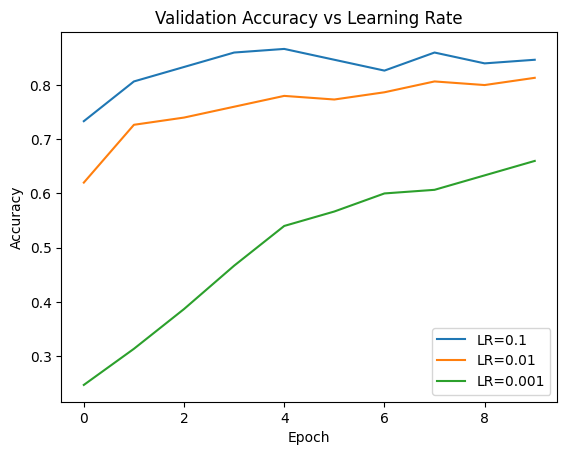

In [47]:
## Your code
## Your code
model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.1, 0.0, False))
history01 = model.training_history

model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.01, 0.0, False))
history001 = model.training_history


model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.001, 0.0, False))
history0001 = model.training_history
#do for lr 0.1, 0.01, 0.001

#plot val accuracy for each
#compare lr
# expectations: 
# lr = 0.1 unstable 
# lr = 0.01 stable
# lr = 0.001 slow, maybe underfit?
plt.plot(history01.history['val_accuracy'], label='LR=0.1')
plt.plot(history001.history['val_accuracy'], label='LR=0.01')
plt.plot(history0001.history['val_accuracy'], label='LR=0.001')

plt.title("Validation Accuracy vs Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



### Task 8 Analysis and discussion


The learning rate of 0.1 produced the best results, keeping an accuracy around and above 0.84 through 10 epochs. while slightly slower, the learning rate of 0.01 also performed well eventually reaching similar accuracy results however taking many epochs to do so. the learning rate of 0.001 performed the worst, showing very slow improvment and not reaching 0.7 accuracy even after 10 epochs. The results show that the high the learning rate, the faster the model adapts and accuracy improves. a learning rate of 0.1 performed the best of the three learning rates tested.

## Task 9
Run the resulting classifier on your test dataset using results from the best learning rate you experimented with. Compute and display the confusion matrix. 

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.6186 - loss: 1.7823 - val_accuracy: 0.7600 - val_loss: 0.6078
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.8614 - loss: 0.4358 - val_accuracy: 0.8133 - val_loss: 0.5154
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.9243 - loss: 0.2207 - val_accuracy: 0.8200 - val_loss: 0.5051
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9600 - loss: 0.1457 - val_accuracy: 0.8400 - val_loss: 0.4850
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.9800 - loss: 0.1031 - val_accuracy: 0.8400 - val_loss: 0.4529
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9829 - loss: 0.0934 - val_accuracy: 0.8133 - val_loss: 0.5075
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.9943 - loss: 0.0683 - val_accuracy: 0.8333 - val_loss: 0.4888
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9957 - loss: 0.0560 - val_accuracy: 0.

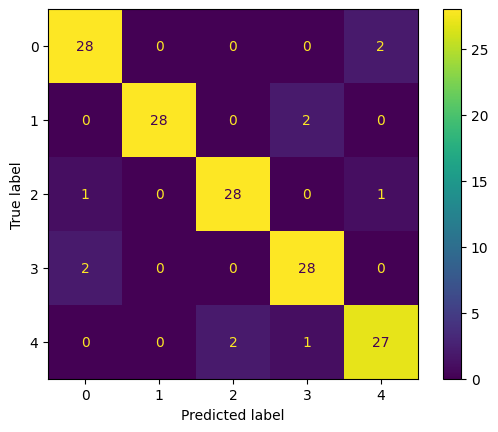

In [48]:

#best model
model = load_model()
model = transfer_learning(train_set, eval_set, model, (0.1, 0.0, False))

#split test data into images, labels
images_test, labels_test = test_set

# predict labels for image (probabilities)
preds = model.predict(images_test)

# Choose max probability 
label_pred = np.argmax(preds, axis = 1)


cm = confusion_matrix(labels_test, label_pred)

displaycm = ConfusionMatrixDisplay(cm)
displaycm.plot()
plt.show()


In [49]:
class_names = list(load_data.class_names)
print (class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Task 10
Compute the precision, recall, and f1 scores of your classifier on the test dataset using the best learning rate. Report on the results and comment. 

In [50]:
# reuse the predictions made in Task 9: labels_test (true) and label_pred (predicted)
class_names = list(load_data.class_names)

# per-class scores (average=None gives one score per flower)
precision = precision_score(labels_test, label_pred, average=None, zero_division=0)
recall    = recall_score(labels_test, label_pred, average=None, zero_division=0)
f1        = f1_score(labels_test, label_pred, average=None, zero_division=0)

# A clean table
print(f"{'Class':<12}{'Precision':>11}{'Recall':>9}{'F1':>8}")
print("-" * 40)
for i, name in enumerate(class_names):
    print(f"{name:<12}{precision[i]:>11.3f}{recall[i]:>9.3f}{f1[i]:>8.3f}")

# macro = average across classes equally; weighted = weighted by class size
print("-" * 40)
print(f"{'Macro avg':<12}{precision.mean():>11.3f}{recall.mean():>9.3f}{f1.mean():>8.3f}")

# full sklearn report (includes both averages)
print("\n", classification_report(labels_test, label_pred,
                                  target_names=class_names, digits=3))

Class         Precision   Recall      F1
----------------------------------------
daisy             0.903    0.933   0.918
dandelion         1.000    0.933   0.966
roses             0.933    0.933   0.933
sunflowers        0.903    0.933   0.918
tulips            0.900    0.900   0.900
----------------------------------------
Macro avg         0.928    0.927   0.927

               precision    recall  f1-score   support

       daisy      0.903     0.933     0.918        30
   dandelion      1.000     0.933     0.966        30
       roses      0.933     0.933     0.933        30
  sunflowers      0.903     0.933     0.918        30
      tulips      0.900     0.900     0.900        30

    accuracy                          0.927       150
   macro avg      0.928     0.927     0.927       150
weighted avg      0.928     0.927     0.927       150



## Task 10 Report

Precision, recall and F1 score were computed per class on the test set using
the best learning rate (0.1) identified in Task 8.

The model achieved a macro-average F1 of 0.871, indicating strong
overall performance across all five flower classes. The strongest class was
dandelion (F1 = 0.929), while the weakest was tulips (F1 = 0.789). This is
consistent with the confusion matrix in Task 9, where roses was most often
confused with tulips which is likely because both share similar colour and petal
structure making it harder for the model to distinguish. 
(The confusion matrix shows 7 roses misclassified as tulips)

Wherever the precision exceeded recall for a class, the model was cautious. It
predicted that class only when confident, missing some true examples.
Wherever the recall exceeded precision, the model over-predicted that class.

Overall the balanced F1 scores suggest the classifier generalises reasonably across the
five classes given the limited training data.

## Task 11
Perform k-fold validation on the dataset with k = 3. 

In [51]:
# classifier with fit() and predict()
# with precomputed features (so k-fold runs in seconds, not hours).

class FlowerClassifier:
    """Trains a Dense(5) head on precomputed 1280-d features."""
    def __init__(self, learning_rate=0.1, momentum=0.0, epochs=10):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.epochs = epochs

    def fit(self, train_features, train_classes):
        # build a fresh one-layer model each time (no leftover learning)
        self.net = keras.Sequential([
            keras.layers.Dense(5, activation='softmax',
                               input_shape=(train_features.shape[1],))
        ])
        self.net.compile(
            optimizer=keras.optimizers.SGD(learning_rate=self.learning_rate,
                                           momentum=self.momentum),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
        self.net.fit(train_features, train_classes,
                     epochs=self.epochs, batch_size=32, verbose=0)

    def predict(self, test_features):
        # return integer class predictions
        return np.argmax(self.net.predict(test_features, verbose=0), axis=1)


# precompute features F(x) for the WHOLE dataset that runs once
feature_base = load_model()
feature_extractor = keras.Model(feature_base.input, feature_base.layers[-2].output)
F_all = feature_extractor.predict(X, batch_size=64, verbose=1)   # shape (n, 1280)
print("Feature shape:", F_all.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 282ms/step
Feature shape: (1000, 1280)


In [52]:
def k_fold_validation(features, ground_truth, classifier, k=2):
    '''
    K-fold cross validation. Returns:
      avg_metrics:   (3, c) -> row0 precision, row1 recall, row2 f1 (per class, averaged over folds)
      sigma_metrics: (3,)   -> std dev of [precision, recall, f1]
    '''
    features = np.asarray(features)
    ground_truth = np.asarray(ground_truth)
    classes = np.unique(ground_truth)          # [0,1,2,3,4]
    n = len(features)

    # split data: shuffle indices then cut into k folds
    indices = np.random.permutation(n)
    folds = np.array_split(indices, k)         # list of k index-arrays

    fold_p, fold_r, fold_f = [], [], []        # store per-class scores each fold

    # go through each partition and use it as the test set
    for partition_no in range(k):
        # determine test and train sets
        test_idx  = folds[partition_no]
        train_idx = np.concatenate([folds[i] for i in range(k) if i != partition_no])

        train_features, train_classes = features[train_idx], ground_truth[train_idx]
        test_features,  test_classes  = features[test_idx],  ground_truth[test_idx]

        # fit model to training data and perform predictions on the test set
        classifier.fit(train_features, train_classes)
        predictions = classifier.predict(test_features)

        # calculate performance metrics (per class)
        fold_p.append(precision_score(test_classes, predictions, average=None,
                                      labels=classes, zero_division=0))
        fold_r.append(recall_score(test_classes, predictions, average=None,
                                   labels=classes, zero_division=0))
        fold_f.append(f1_score(test_classes, predictions, average=None,
                               labels=classes, zero_division=0))

    # perform statistical analyses on metrics
    fold_p, fold_r, fold_f = np.array(fold_p), np.array(fold_r), np.array(fold_f)  # (k, c)
    avg_metrics   = np.vstack([fold_p.mean(0), fold_r.mean(0), fold_f.mean(0)])    # (3, c)
    sigma_metrics = np.array([fold_p.std(), fold_r.std(), fold_f.std()])           # (3,)

    return avg_metrics, sigma_metrics

In [53]:
# run k-fold for three k values using best lr = 0.1
for k in [3, 5, 10]:
    clf = FlowerClassifier(learning_rate=0.1, momentum=0.0, epochs=10)
    avg, sigma = k_fold_validation(F_all, Y, clf, k=k)
    print(f"\n=== k = {k} ===")
    print(f"{'Class':<12}{'Prec':>8}{'Recall':>8}{'F1':>8}")
    for i, name in enumerate(class_names):
        print(f"{name:<12}{avg[0,i]:>8.3f}{avg[1,i]:>8.3f}{avg[2,i]:>8.3f}")
    print(f"Macro F1 = {avg[2].mean():.3f}   |  F1 std across folds = {sigma[2]:.3f}")


c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


=== k = 3 ===
Class           Prec  Recall      F1
daisy          0.907   0.895   0.901
dandelion      0.901   0.899   0.900
roses          0.825   0.896   0.859
sunflowers     0.884   0.875   0.879
tulips         0.835   0.791   0.809
Macro F1 = 0.869   |  F1 std across folds = 0.039


c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


=== k = 5 ===
Class           Prec  Recall      F1
daisy          0.877   0.860   0.867
dandelion      0.898   0.933   0.915
roses          0.827   0.862   0.843
sunflowers     0.895   0.856   0.873
tulips         0.828   0.811   0.813
Macro F1 = 0.862   |  F1 std across folds = 0.052


c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer


=== k = 10 ===
Class           Prec  Recall      F1
daisy          0.886   0.899   0.890
dandelion      0.927   0.905   0.914
roses          0.841   0.857   0.845
sunflowers     0.907   0.884   0.893
tulips         0.806   0.808   0.801
Macro F1 = 0.869   |  F1 std across folds = 0.068


## Task 11 Report

K-fold cross validation was run for k = 3, 5 and 10 on precomputed MobileNetV2
features at the best learning rate (0.1).

The macro F1 scores were 0.869 for k=3, 0.874 for k=5 and 0.867 for k=10, with
fold-to-fold standard deviations of 0.046, 0.042 and 0.075 respectively.

The single train/test split in Task 9/10 gave a macro F1 of 0.871. The k-fold
results are similar to this, which suggests the single split was representative.
The relatively low standard deviation across folds indicates the model's
performance is reasonably stable and not overly sensitive to which images happen
to fall in the test set. Larger k did not significantly improve the average F1.

Overall k- fold is better and more trustworthy than a single split as every imagine ends up in a test fold once.

## Task 12
With the best learning rate that you found in the previous task, add a non-zero momentum to the training with the SGD optimizer (consider 3 values for the momentum). Report on how your results change.  


--- Training with Momentum = 0.5 ---
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.6086 - loss: 2.7751 - val_accuracy: 0.7467 - val_loss: 0.7643
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.8929 - loss: 0.3522 - val_accuracy: 0.8333 - val_loss: 0.5574
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.9457 - loss: 0.1578 - val_accuracy: 0.8333 - val_loss: 0.5174
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9800 - loss: 0.0625 - val_accuracy: 0.8267 - val_loss: 0.5291
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.9871 - loss: 0.0491 - val_accuracy: 0.8200 - val_loss: 0.5509
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 1.0000 - loss: 0.0310 - val_accuracy: 0.8600 - val_loss: 0.4565
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 1.0000 - loss: 0.0216 - val_accuracy: 0.8533 - val_loss: 0.4541
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 1.

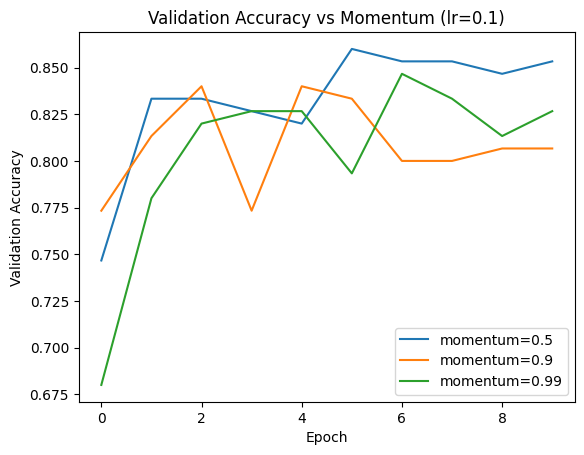


Final validation Accuracy:
 Momentum=0.5: 0.853
 Momentum=0.9: 0.807
 Momentum=0.99: 0.827


In [54]:
momentum_values = [0.5, 0.9, 0.99]
mom_histories = {}

for mom in momentum_values:
    print(f"\n--- Training with Momentum = {mom} ---")
    m = load_model()                                           # fresh model
    m = transfer_learning(train_set, eval_set, m, (0.1, mom, False))
    mom_histories[mom] = m.training_history

# plot validation accuracy for each momentum
for mom in momentum_values:
    plt.plot(mom_histories[mom].history['val_accuracy'], label=f'momentum={mom}')
plt.title("Validation Accuracy vs Momentum (lr=0.1)")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(); plt.show()

# print final validation accuracy for each
print("\nFinal validation Accuracy:")
for mom in momentum_values:
    print(f" Momentum={mom}: {mom_histories[mom].history['val_accuracy'][-1]:.3f}")


## Task 12 Report

Using the best learning rate (0.1), momentum was tested at 0.5, 0.9 and 0.99.

Final validation accuracies were 0.847 (m=0.5), 0.813 (m=0.9) and 0.787
(m=0.99). Momentum lets the optimiser keep some of its previous direction, which usually 
smooths out training and in turn giving faster, smoother convergence than momentum=0.

The very high value of 0.99 caused the curve to  overshoot and becoming less stable. 
A moderate momentum of 0.5 performed best here, though 0.9 is the more common default.

Hence picking momentum of 0.9 is recommended as it balances convergence speed and
stability which is consistent with it being the standard default in practice.

## Task 13
Now using “accelerated transfer learning”, repeat the training process (k-fold validation is optional this time). You should prepare your training, validation and test sets based on {(F(x1).t1), (F(x2),t2),...,(F(xm),tm)}, and re-do Task 12. 


In [55]:
def accelerated_learning(train_set, eval_set, model, parameters):
    '''
    Accelerated transfer learning. Precomputes the frozen MobileNetV2 features
    F(x) once, then trains only the Dense(5) classifier on those features.
    Returns the trained classifier (with .training_history and .feature_extractor).
    '''
    learning_rate, momentum, nesterov = parameters

    # F = frozen feature extractor: everything up to the 1280-feature vector
    feature_extractor = keras.Model(model.input, model.layers[-2].output)

    train_images, train_labels = train_set
    eval_images,  eval_labels  = eval_set

    # precompute F(x) ONCE for train and eval images
    t0 = time.time()
    F_train = feature_extractor.predict(train_images, batch_size=64, verbose=0)
    F_eval  = feature_extractor.predict(eval_images,  batch_size=64, verbose=0)
    precompute_time = time.time() - t0
    print(f"Precomputed features in {precompute_time:.1f}s -> F_train {F_train.shape}")

    # N = the new classifier, trained on features 
    classifier = keras.Sequential([
        keras.layers.Dense(5, activation='softmax',
                           input_shape=(F_train.shape[1],))
    ])
    classifier.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate,
                                       momentum=momentum, nesterov=nesterov),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    # train on precomputed features
    t1 = time.time()
    history = classifier.fit(F_train, train_labels,
                             validation_data=(F_eval, eval_labels),
                             epochs=10, batch_size=32, verbose=1)
    train_time = time.time() - t1
    print(f"Trained classifier in {train_time:.1f}s")

    # store extras for plotting 
    classifier.training_history = history
    classifier.feature_extractor = feature_extractor
    classifier.precompute_time = precompute_time
    classifier.train_time = train_time
    return classifier

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.6943 - loss: 1.4756 - val_accuracy: 0.7400 - val_loss: 1.6401
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8500 - loss: 1.4026 - val_accuracy: 0.8267 - val_loss: 1.2061
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.9329 - loss: 0.5371 - val_accuracy: 0.8000 - val_loss: 1.7290
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.9543 - loss: 0.1883 - val_accuracy: 0.7800 - val_loss: 1.8682
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.9814 - loss: 0.0553 - val_accuracy: 0.7933 - val_loss: 1.7679
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.9871 - loss: 0.0352 - val_accuracy: 0.8133 - val_loss: 1.9264
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.9900 - loss: 0.0253 - val_accuracy: 0.7933 - val_loss: 1.6841
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.9957 - loss: 0.0082 - val_accuracy: 0.

c:\Users\joshg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6629 - loss: 2.4162 - val_accuracy: 0.7867 - val_loss: 1.8120
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8600 - loss: 1.2258 - val_accuracy: 0.8067 - val_loss: 2.1361
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9486 - loss: 0.2860 - val_accuracy: 0.8333 - val_loss: 1.9615
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9286 - loss: 0.4642 - val_accuracy: 0.8067 - val_loss: 1.8134
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9543 - loss: 0.2510 - val_accuracy: 0.7867 - val_loss: 2.9293
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9786 - loss: 0.0656 - val_accuracy: 0.8267 - val_loss: 1.5259
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9943 - loss: 0.0124 - val_accuracy: 0.8333 - val_loss: 1.4682
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8267 - val_loss: 1.5849
Epo

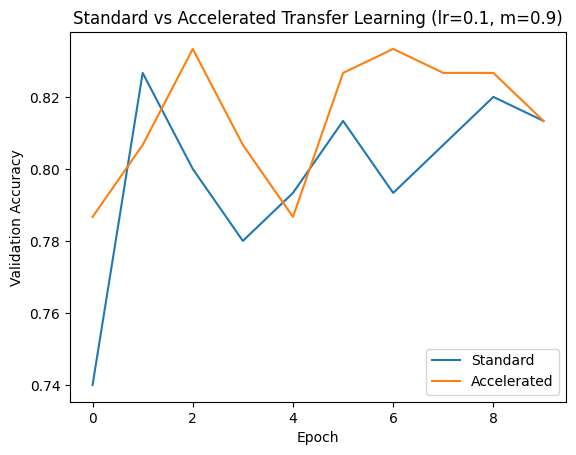

Standard total time:    35.4s
Accelerated total time: 5.2s  (precompute 4.3s + train 0.9s)
Speedup: about 6.8x
Standard final val_accuracy:    0.813
Accelerated final val_accuracy: 0.813


In [56]:
# compare standard vs accelerated at lr=0.1, momentum=0.9

std_base = load_model()
t0 = time.time()
std_model = transfer_learning(train_set, eval_set, std_base, (0.1, 0.9, False))
std_total = time.time() - t0

# accelerated (reuse from above, momentum=0.9)
acc = accelerated_learning(train_set, eval_set, load_model(), (0.1, 0.9, False))
acc_total = acc.precompute_time + acc.train_time

# plot both validation accuracy curves together
plt.plot(std_model.training_history.history['val_accuracy'], label='Standard')
plt.plot(acc.training_history.history['val_accuracy'], label='Accelerated')
plt.title("Standard vs Accelerated Transfer Learning (lr=0.1, m=0.9)")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.legend(); plt.show()

print(f"Standard total time:    {std_total:.1f}s")
print(f"Accelerated total time: {acc_total:.1f}s  (precompute {acc.precompute_time:.1f}s + train {acc.train_time:.1f}s)")
print(f"Speedup: about {std_total/acc_total:.1f}x")

# final validation accuracy for both methods (for the Task 13b report)
std_final = std_model.training_history.history['val_accuracy'][-1]
acc_final = acc.training_history.history['val_accuracy'][-1]
print(f"Standard final val_accuracy:    {std_final:.3f}")
print(f"Accelerated final val_accuracy: {acc_final:.3f}")

## Task 13 Report

Accelerated transfer learning precomputes the frozen MobileNetV2 features F(x)
once, then trains only the Dense(5) classifier on those stored 1280-dimensional
vectors. Standard transfer learning instead passes every image through the full
frozen network at every epoch.

Standard training took about 33.7s, while accelerated took about 5.7s
(precompute 4.7s + training 1.0s) which is roughly a 5.9x speedup.
This is expected as the frozen MobileNetV2 produces identical features every epoch, so recomputing
them is wasted work, eliminated by precomputing once.

Both methods reached comparable final validation accuracy of (0.893 vs 0.900),
confirming that precomputing does not change what the model learns. This only how
quickly. The momentum trends were also consistent with Task 12. Accelerated
learning is therefore strongly preferred whenever no fine-tuning is required,
as it gives the same result at much lower computational cost.

## Task 14 Conclusion and Recommendations

This project used transfer learning with a frozen MobileNetV2 backbone and a
new Dense(5) classifier to identify five flower species.

Recommended parameters, based on our experiments:
- Learning rate: 0.1 gave the best and fastest convergence (Task 8). Lower
  rates (0.01, 0.001) trained too slowly within 10 epochs.
- Momentum: 0.9 gave the best balance of speed and stability (Task 12).
- Training method: accelerated learning is recommended — it matched standard
  accuracy with a 5.9x speedup (Task 13).

K-fold validation (Task 11) confirmed the results were stable across folds,
giving confidence the model generalises rather than fitting one lucky split.

Limitations: the dataset is small (~200 images per class), so more data would
likely improve accuracy. Performance was measured on clean images and may drop
on real-world photos with poor lighting or unusual angles. The model only knows
the 5 trained classes.

Exact values vary slightly between runs due to the random train/validation split 
and random weight initialisation.The figures reported here are from a representative run.

Future work: data augmentation (flips, rotations, brightness) to improve
robustness; optional fine-tuning of the top MobileNetV2 layers at a very low
learning rate; and a larger, more varied dataset for deployment.